<h1 align="center">Logistic Regression (Binary Classification)</h1>

In [183]:
import pandas as pd
df = pd.read_csv("car_ownership.csv")
df.head(3)

,monthly_salary,owns_car
0,22000,0
1,25000,0
2,47000,1


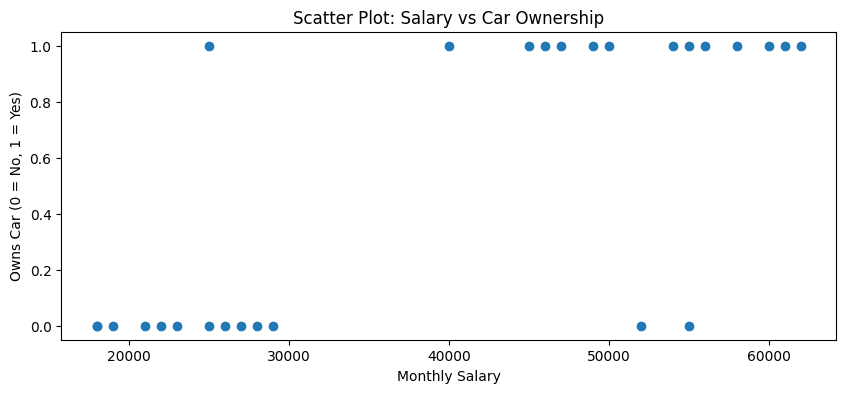

In [185]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.scatter(df["monthly_salary"], df["owns_car"])
plt.xlabel("Monthly Salary")
plt.ylabel("Owns Car (0 = No, 1 = Yes)")
plt.title("Scatter Plot: Salary vs Car Ownership")
plt.show()

In [186]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = df[['monthly_salary']]
y = df["owns_car"]

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.3, random_state = 42)

model = LogisticRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8888888888888888

In [187]:
X_test

,monthly_salary
8,62000
13,29000
9,61000
21,26000
0,22000
11,28000
16,25000
17,58000
12,27000


In [188]:
y_test.tolist()

[1, 0, 1, 0, 0, 0, 1, 1, 0]

In [212]:
y_pred = model.predict(X_test)  ##false for salary = 25000  8 out of 9 corect =  88.88 percent

In [214]:
## model.score = accuracy = right prediction / total predictions

In [216]:
## now calculation the actual probability. when we do model.predict for log reg then if the prob is above 0.5 ->1 and below 0.5->0

## to know the actual probability-

model.predict_proba(X_test)  ##(1-probability, actual probability)

array([[0.04530932, 0.95469068],
       [0.80955349, 0.19044651],
       [0.05158003, 0.94841997],
       [0.86480041, 0.13519959],
       [0.91687254, 0.08312746],
       [0.82967465, 0.17032535],
       [0.87995016, 0.12004984],
       [0.07564619, 0.92435381],
       [0.84806892, 0.15193108]])

In [218]:
model.coef_, model.intercept_ ## coef anf intercept o the straight line without applying the sigmoid fn

(array([[0.00013621]]), array([-5.39725076]))

In [220]:
## predicting class without using the logistic regression class
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

In [222]:
def prediction_function(salary, model):
    z = model.coef_* salary + model.intercept_
    y = sigmoid(z[0][0])  ## it'll be a 2d array and we want the first element. we can also simply use sigmoid(z) but it'll throw a warning
    return y
    

In [224]:
prediction_function(62000, model)

0.954690678813166

In [225]:
## calculating precision and recall

In [232]:
y_pred

array([1, 0, 1, 0, 0, 0, 0, 1, 0])

In [236]:
y_test.tolist()

[1, 0, 1, 0, 0, 0, 1, 1, 0]

In [228]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.75      0.86         4

    accuracy                           0.89         9
   macro avg       0.92      0.88      0.88         9
weighted avg       0.91      0.89      0.89         9



In [244]:
## calculating f1 score

f1_score_0 = 2 * ((0.83 * 1)/(0.83 + 1)) ## for class 0
f1_score_1 = 2 * ((1.0 * 0.75)/(0.75 + 1)) ## for class 1
f1_score_0, f1_score_1

(0.9071038251366119, 0.8571428571428571)

In [246]:
## confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[5, 0],
       [1, 3]])

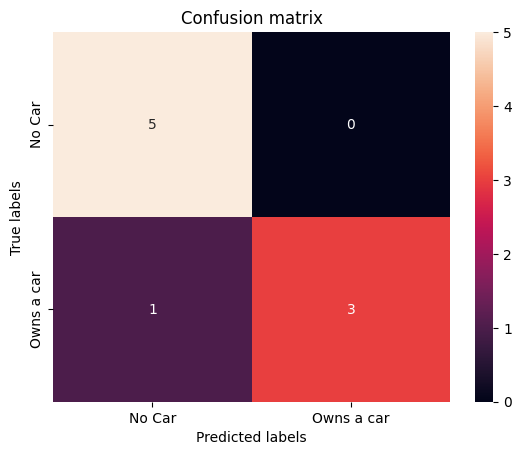

In [262]:
import seaborn as sns

classes = ["No Car", "Owns a car"]
sns.heatmap(cm, annot = True, xticklabels=classes, yticklabels=classes)
plt.title("Confusion matrix")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()